Árboles de Decisión

In [4]:
#Importamos las librerias 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [6]:
#Cargamos el dataset y mostramos las 5 primeras filas
data = pd.read_csv("winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
data.shape

(1599, 12)

In [10]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [12]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

(array([ 10.,   0.,  53.,   0., 681.,   0., 638.,   0., 199.,  18.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

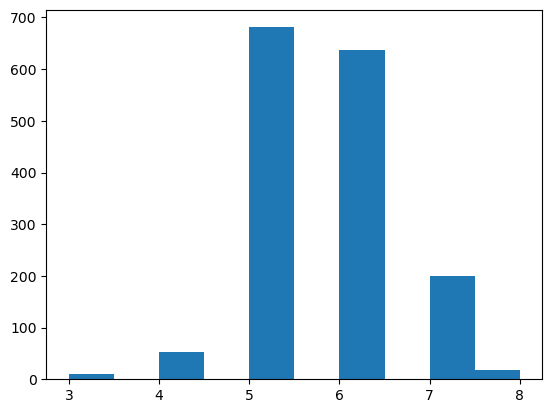

In [14]:
plt.hist(data.quality)

Como se puede observar en el historigrama la calidad minima del vino es de 3 y la calidad maxima es de 8, podemos concluir que el dataset esta equilibrado.

<Axes: xlabel='alcohol', ylabel='volatile acidity'>

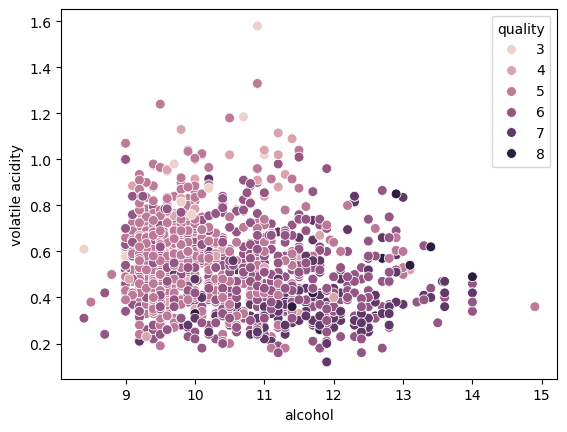

In [52]:
sns.scatterplot(x="alcohol", y="volatile acidity", hue="quality", data=data, s=50)

<Axes: xlabel='chlorides', ylabel='sulphates'>

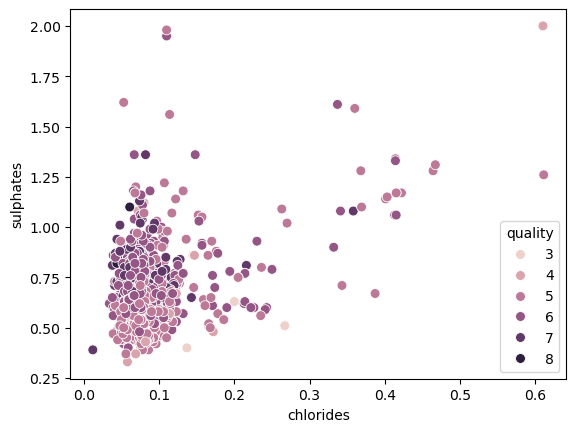

In [58]:
sns.scatterplot(x="chlorides", y="sulphates", hue="quality", data=data, s=50)

<Axes: xlabel='alcohol', ylabel='citric acid'>

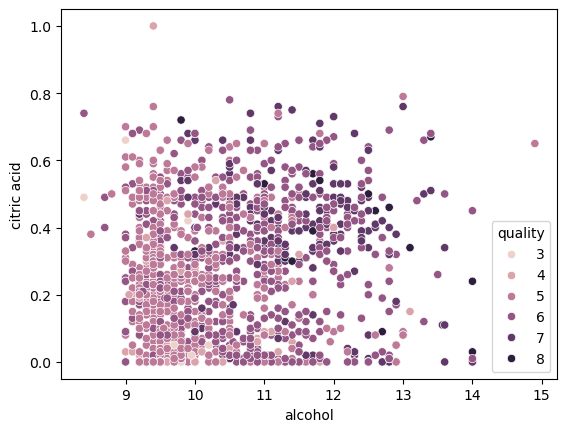

In [40]:
sns.scatterplot(x="alcohol", y="citric acid", hue="quality", data=data, s=50)

<Axes: xlabel='volatile acidity', ylabel='citric acid'>

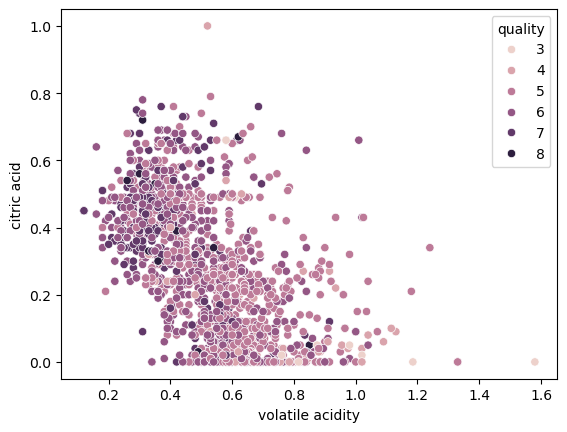

In [42]:
sns.scatterplot(x="volatile acidity", y="citric acid", hue="quality", data=data, s=50)

<Axes: xlabel='residual sugar', ylabel='density'>

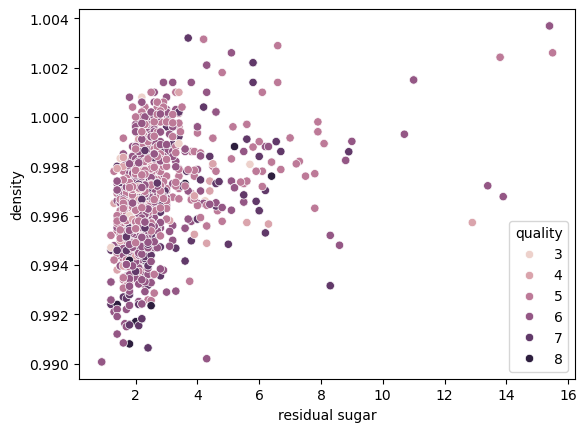

In [44]:
sns.scatterplot(x="residual sugar", y="density", hue="quality", data=data)

<Axes: xlabel='fixed acidity', ylabel='pH'>

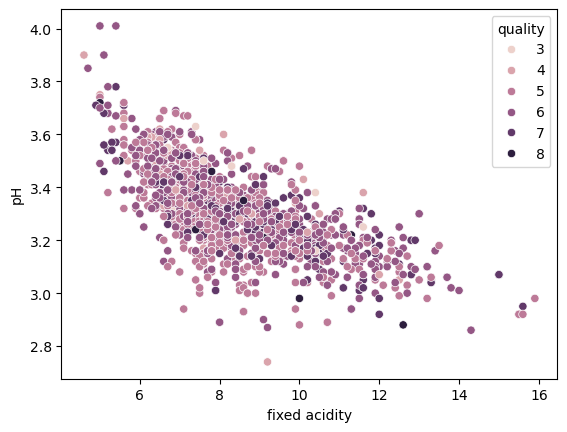

In [46]:
sns.scatterplot(x="fixed acidity", y="pH", hue="quality", data=data, s=50)

<Axes: xlabel='free sulfur dioxide', ylabel='total sulfur dioxide'>

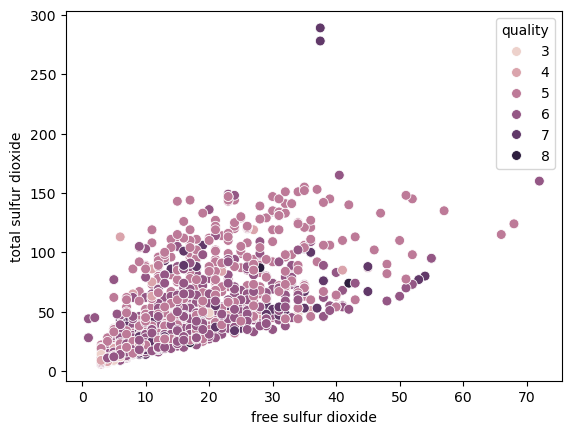

In [54]:
sns.scatterplot(x="free sulfur dioxide", y="total sulfur dioxide", hue="quality", data=data, s=50)

Como se puede observar en los diagramas de dispersión, la calidad del vino parece estar altamente influenciada por el nivel de alcohol y negativamente afectada por la acidez volátil. Otras variables como los sulfatos, el cloruro y el ácido cítrico también aportan información útil. En cambio, variables como el pH, el azúcar residual o la densidad muestran una influencia limitada cuando se observan de forma aislada.

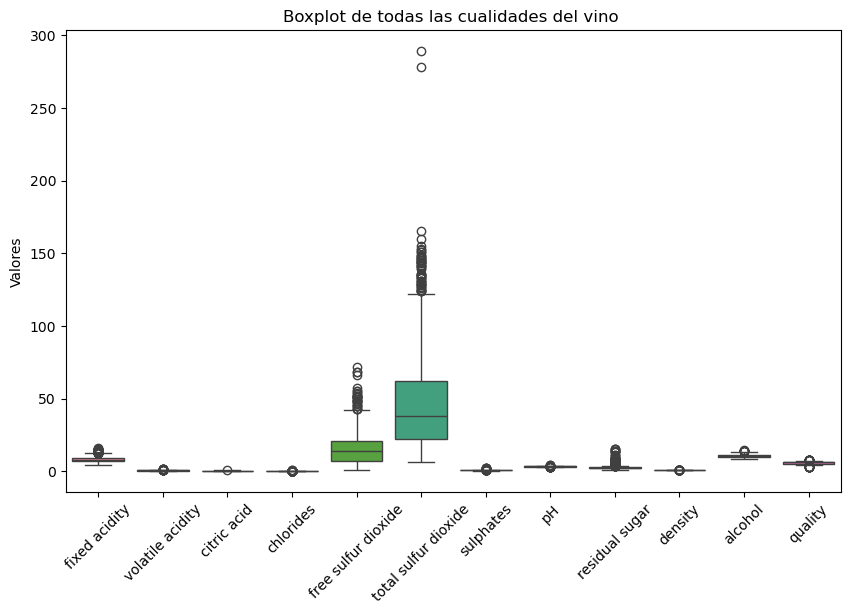

In [125]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide','total sulfur dioxide' , 'sulphates','pH','residual sugar','density', 'alcohol', 'quality']])
plt.xticks(rotation=45)
plt.title('Boxplot de todas las cualidades del vino ')
plt.ylabel('Valores')
plt.show()

In [580]:
predictors_col = ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide','total sulfur dioxide' , 'sulphates','pH','residual sugar','density', 'alcohol']
target_col = ['quality']

In [582]:
predictors = data[predictors_col]
target = data[target_col]

In [584]:
predictors

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,sulphates,pH,residual sugar,density,alcohol
0,7.4,0.700,0.00,0.076,11.0,34.0,0.56,3.51,1.9,0.99780,9.4
1,7.8,0.880,0.00,0.098,25.0,67.0,0.68,3.20,2.6,0.99680,9.8
2,7.8,0.760,0.04,0.092,15.0,54.0,0.65,3.26,2.3,0.99700,9.8
3,11.2,0.280,0.56,0.075,17.0,60.0,0.58,3.16,1.9,0.99800,9.8
4,7.4,0.700,0.00,0.076,11.0,34.0,0.56,3.51,1.9,0.99780,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,0.090,32.0,44.0,0.58,3.45,2.0,0.99490,10.5
1595,5.9,0.550,0.10,0.062,39.0,51.0,0.76,3.52,2.2,0.99512,11.2
1596,6.3,0.510,0.13,0.076,29.0,40.0,0.75,3.42,2.3,0.99574,11.0
1597,5.9,0.645,0.12,0.075,32.0,44.0,0.71,3.57,2.0,0.99547,10.2


In [586]:
target

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [588]:
corr = predictors.corr()
corr

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,sulphates,pH,residual sugar,density,alcohol
fixed acidity,1.000000,-0.256131,0.671703,0.093705,-0.153794,-0.113181,0.183006,-0.682978,0.114777,0.668047,-0.061668
volatile acidity,-0.256131,1.000000,-0.552496,0.061298,-0.010504,0.076470,-0.260987,0.234937,0.001918,0.022026,-0.202288
citric acid,0.671703,-0.552496,1.000000,0.203823,-0.060978,0.035533,0.312770,-0.541904,0.143577,0.364947,0.109903
chlorides,0.093705,0.061298,0.203823,1.000000,0.005562,0.047400,0.371260,-0.265026,0.055610,0.200632,-0.221141
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.005562,1.000000,0.667666,0.051658,0.070377,0.187049,-0.021946,-0.069408
total sulfur dioxide,-0.113181,0.076470,0.035533,0.047400,0.667666,1.000000,0.042947,-0.066495,0.203028,0.071269,-0.205654
sulphates,0.183006,-0.260987,0.312770,0.371260,0.051658,0.042947,1.000000,-0.196648,0.005527,0.148506,0.093595
pH,-0.682978,0.234937,-0.541904,-0.265026,0.070377,-0.066495,-0.196648,1.000000,-0.085652,-0.341699,0.205633
residual sugar,0.114777,0.001918,0.143577,0.055610,0.187049,0.203028,0.005527,-0.085652,1.000000,0.355283,0.042075
density,0.668047,0.022026,0.364947,0.200632,-0.021946,0.071269,0.148506,-0.341699,0.355283,1.000000,-0.496180


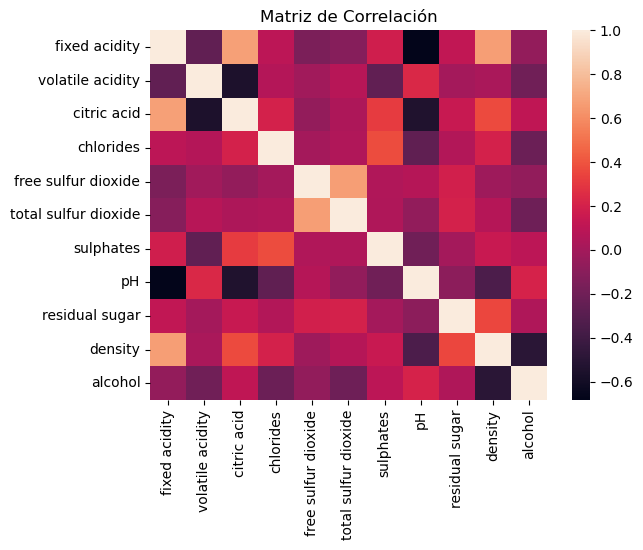

In [590]:
sns.heatmap(corr)
plt.title('Matriz de Correlación')
plt.show()

In [725]:
X_train, X_test, y_train, y_test = train_test_split(predictors, target, test_size=0.20, random_state=13)

In [727]:
tree = DecisionTreeClassifier()

In [729]:
arbol = tree.fit(X_train, y_train)

[Text(0.5155136153567329, 0.9772727272727273, 'x[10] <= 10.525\ngini = 0.646\nsamples = 1279\nvalue = [9.0, 45.0, 535.0, 514.0, 164.0, 12.0]'),
 Text(0.2368452848426267, 0.9318181818181818, 'x[6] <= 0.535\ngini = 0.546\nsamples = 774\nvalue = [6, 29, 450, 260, 29, 0]'),
 Text(0.3761794500996798, 0.9545454545454546, 'True  '),
 Text(0.042409230955113876, 0.8863636363636364, 'x[1] <= 0.335\ngini = 0.367\nsamples = 183\nvalue = [2, 13, 143, 24, 1, 0]'),
 Text(0.015465474536337825, 0.8409090909090909, 'x[3] <= 0.082\ngini = 0.562\nsamples = 11\nvalue = [0, 1, 4, 6, 0, 0]'),
 Text(0.011599105902253368, 0.7954545454545454, 'x[3] <= 0.059\ngini = 0.406\nsamples = 8\nvalue = [0, 1, 1, 6, 0, 0]'),
 Text(0.007732737268168912, 0.75, 'x[0] <= 8.05\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1, 0, 0, 0]'),
 Text(0.003866368634084456, 0.7045454545454546, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0, 0]'),
 Text(0.011599105902253368, 0.7045454545454546, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0, 0,

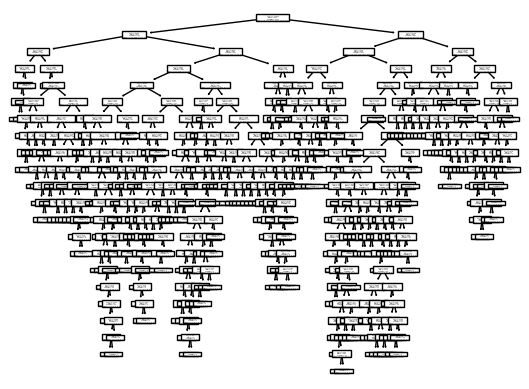

In [731]:
plot_tree(arbol)

In [732]:
predicciones = arbol.predict(X_test)

In [733]:
predicciones

array([7, 7, 5, 5, 6, 5, 5, 8, 5, 7, 5, 6, 5, 6, 7, 6, 6, 5, 5, 7, 5, 6,
       7, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 6, 5, 6, 5, 5, 6, 7, 6, 5, 6, 6,
       6, 5, 6, 6, 5, 6, 6, 4, 6, 5, 7, 5, 5, 6, 6, 5, 6, 5, 5, 5, 7, 7,
       6, 7, 5, 6, 6, 5, 5, 6, 4, 5, 5, 5, 5, 5, 7, 6, 6, 5, 5, 5, 7, 5,
       7, 5, 6, 6, 5, 7, 7, 6, 5, 6, 6, 6, 6, 7, 6, 5, 6, 6, 3, 6, 5, 7,
       7, 7, 6, 6, 5, 5, 6, 7, 5, 5, 5, 5, 5, 6, 5, 4, 5, 5, 6, 7, 6, 5,
       6, 7, 5, 5, 7, 5, 6, 7, 6, 5, 3, 6, 7, 4, 6, 5, 6, 5, 5, 6, 5, 5,
       5, 5, 5, 5, 6, 5, 6, 7, 6, 4, 6, 5, 6, 5, 6, 5, 5, 5, 5, 5, 6, 5,
       5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6, 6, 5, 5, 5, 6, 5, 5, 7, 5, 6, 7,
       5, 5, 6, 6, 7, 5, 6, 6, 6, 5, 5, 6, 8, 5, 6, 6, 7, 5, 5, 5, 6, 7,
       4, 5, 6, 5, 6, 6, 5, 5, 4, 6, 6, 6, 5, 5, 5, 6, 6, 5, 5, 5, 5, 6,
       6, 5, 5, 6, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 6, 7, 5, 5, 5, 6, 7, 5,
       6, 5, 6, 7, 6, 5, 5, 5, 6, 5, 6, 5, 6, 6, 5, 5, 5, 4, 6, 5, 7, 5,
       6, 7, 5, 5, 5, 6, 5, 7, 5, 6, 5, 5, 5, 5, 5,

In [734]:
# Examinamos la matriz de confusión
pd.crosstab(np.array([y[0] for y in y_test.values.tolist()]), predicciones, rownames=['Actual'], colnames=['Predicciones'])

Predicciones,3,4,5,6,7,8
Actual,,,,,,
3,0,0,0,1,0,0
4,0,3,4,0,1,0
5,2,1,109,29,5,0
6,0,4,33,72,13,2
7,0,0,4,12,19,0
8,0,0,1,2,3,0


In [735]:
accuracy = accuracy_score(y_test,predicciones)
accuracy

0.634375

In [736]:
precision = precision_score(y_test, predicciones, average='weighted',zero_division=0)
precision

0.6299242434791327

In [737]:
recall = recall_score(y_test, predicciones, average='weighted')
recall

0.634375

In [738]:
f1 = f1_score(y_test, predicciones, average='weighted')
f1

0.6314530723905725